In [1]:
import numpy as np
import CDEF
from CDEF.bipyramids import bipy_curve, import_config
import pickle
import time
import os
from datetime import datetime
from scipy.optimize import root, Bounds, differential_evolution
import matplotlib.pyplot as plt
import scipy


# make png of results
def plot_fitresults(data, fit_values, unitmodel_args, distribution, N):

    if 'box' in unitmodel_args.keys():
        unitscattering = unitmodel_args
    else:
        if len(fit_values) > 5:
            unitscattering = bipy_curve(fit_values[5], **unitmodel_args)
        else:
            unitscattering = bipy_curve(**unitmodel_args)

    #q-range of fit
    qvec = np.logspace(-3,0,1000)

    fit = CDEF.scattering_model(unitscattering, qvec, *fit_values[:4], distribution)

    fig, ax = plt.subplots(nrows=2, ncols=1, sharex='col', sharey='row', gridspec_kw={'height_ratios':[3,1]})

    r = fit_values[1]
    r_bipy = 2*r / (1 + np.cos(np.pi/5))
    e_bipy = 2*r_bipy * np.sin(np.pi/5)

    ax[0].set_title(f'bipyramid mean side length = {e_bipy:.1f} nm, {N} pts')
    ax[0].set_xscale('log')
    ax[0].set_ylabel(r'$I$ / a. u.', fontsize=12)
    ax[0].set_yscale('log')

    #Frame limits
    ax[0].set_ylim([1e-1, 1e5])
    ax[0].set_xlim([3e-2, 1e0])

    ax[0].errorbar(data[:,0], data[:,1], 
                yerr = data[:,3], fmt='.', ecolor='k', 
                capsize= 2, capthick=1, alpha=0.6, markersize = 5, label = 'Experimental data', zorder=1)
    ax[0].loglog(fit[:,0], fit[:,1], label='Fit')

    ax[0].legend()

    #########################################
    ax[1].set_xlabel(r'$q$ / nm$^{-1}$', fontsize=12)
    ax[1].set_ylabel(r'$I$ / $I_{\mathrm{Fit}}$', fontsize=12)

    #Frame limits
    ax[1].set_ylim([0.85, 1.15])
    norm = np.abs(np.interp(data[:, 0], fit[:, 0], fit[:, 1]))
    
    # norm = CDEF.scattering_model(unitscattering, data[:, 0], *fit_values[:4], distribution)[:,1]

    ax[1].errorbar(data[:, 0], data[:, 1]/norm, 
                yerr = np.abs(data[:, 3])/norm, 
                fmt='.', ecolor='k', capsize= 2, capthick=1, alpha=0.6, markersize = 5, 
                label = 'Experimental data', zorder=1)

    ax[1].plot(fit[:,0], fit[:,1]/fit[:,1], label='Fit')


562


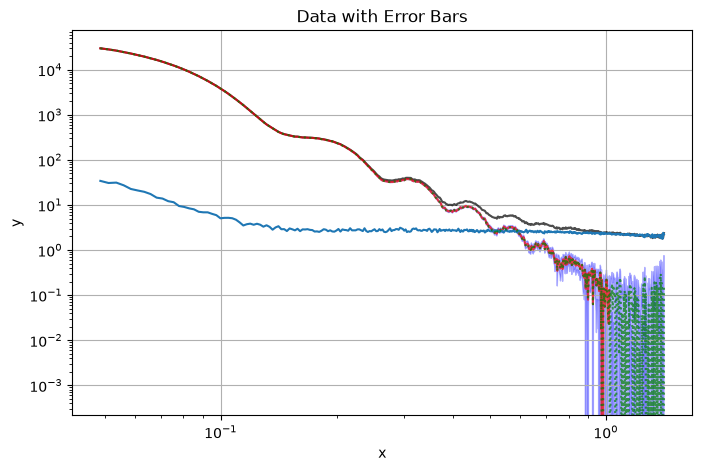

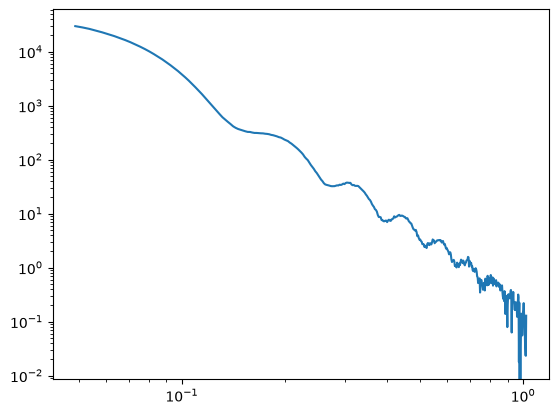

In [ ]:
# Read measured data 

data = np.loadtxt("/messung/kmc/daten/2025/25_kw32/saxs_25_kw32/close_position/hdf_fcm_2025kw32_00097_Sample-Y_-8.0_Sample-X_44.7.dat")
background = np.loadtxt("/messung/kmc/daten/2025/25_kw32/saxs_25_kw32/close_position/hdf_fcm_2025kw32_00097_Sample-Y_-8.0_Sample-X_54.5.dat")
# data = np.loadtxt("/messung/kmc/daten/2025/25_kw32/saxs_25_kw32/hdf_fcm_2025kw32_00097_Sample-Y_-8.0_Sample-X_39.8.dat")

x0 = 0
x_end = 400
print(len(data))
x = data[:,0]
y = data[:,1] - background[:,1]
yerr = np.sqrt(data[:,-1]**2 + background[:,-1]**2)

plt.figure(figsize=(8,5))
# plt.errorbar(x, y, yerr=yerr, fmt='o', capsize=3, ecolor='red', markerfacecolor='blue', markersize=4)
# plt.plot(x, y, 'b-', label='y', alpha=0.3)
plt.fill_between(x, y - yerr, y + yerr, color='blue', alpha=0.3, label='uncertainty')
plt.plot(data[:,0], data[:,1], 'k-', label='y', alpha=0.7)
plt.plot(x[x0:x_end], y[x0:x_end], 'r-', label='y', alpha=0.7)
plt.plot(background[:,0], background[:,1])
plt.plot(x, y, 'g:', label='y', alpha=0.7)
plt.xlabel("x")
plt.ylabel("y")
plt.yscale("log")
plt.xscale("log")
plt.title("Data with Error Bars")
plt.grid(True)
plt.show()

data[:,1] -= background[:,1]
data[:,2:] = np.sqrt(data[:,2:]**2 + background[:,2:]**2)
data = data[x0:x_end,:]

fig, ax = plt.subplots()
ax.loglog(data[:,0], data[:,1])

# create, show and export ideal pentagonal bipyramid

base_corners = 5
side_length = 1
height = side_length * 0.1 * np.sqrt(50-10*np.sqrt(5))
radius = side_length / (2*np.sin(np.pi/base_corners))
fillet_radius = radius * 0.0
# port = 3940

# bipy = bipyramid(fillet_radius=fillet_radius, R=radius, h=height, base_corners=base_corners)
bipy = bipy_curve(fillet_radius=fillet_radius, radius=radius, height=height, base_corners=base_corners, N=100000, model='bipyramid')

# show(bipy, port=port)

# export_stl(bipy, "stl/bipy.stl")

unitscattering calculation time = 1.9414794445037842 s
Optimization terminated successfully.
         Current function value: 2.888836
         Iterations: 5
         Function evaluations: 201
Calculation time = 7.853452682495117 s
fit results = [2.78668567e-06 4.92334234e+01 2.42140780e+00 1.18833289e-01]
chi_squared = 2.888835707008403
mean radius = 54.4 nm
mean side length = 64.0 nm


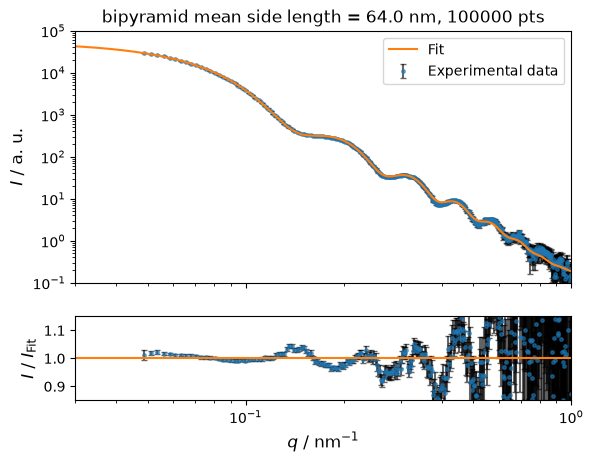

In [3]:
%load_ext autoreload
%autoreload 2

N = 100000

distribution = 'lognormal'
N_C, mean, sigma, c0 =  3e-7, 50, 1, 0
inital_guess = N_C, mean, sigma, c0

unitmodel_args = {'N': N,
                  'base_corners': base_corners,
                  'radius': radius,
                  'height': height,
                  'fillet_radius': fillet_radius}

tic = time.time()
unitscattering = bipy_curve(**unitmodel_args)
print('unitscattering calculation time = {} s'.format(time.time()-tic))
fit_result = scipy.optimize.minimize(CDEF.chi_squared, (inital_guess), args=(data, unitscattering, distribution), 
                                     method = 'Powell', options={'disp' : True})
toc = time.time()
print('Calculation time = {} s'.format(toc-tic))
print(f'fit results = {fit_result.x}')
print(f'chi_squared = {CDEF.chi_squared(fit_result.x, data, unitscattering, distribution)}')


r_mean = fit_result.x[1]
r_bipy = 2*r_mean / (1 + np.cos(np.pi/5))
e_bipy = 2*r_bipy * np.sin(np.pi/5)
print(f"mean radius = {r_bipy:.1f} nm")
print(f"mean side length = {e_bipy:.1f} nm")


plot_fitresults(data, fit_result.x, unitmodel_args, distribution, N)